# Phase 10 — `global_2004` : le test équitable des modèles ML

**Question de soutenance :** que reste-t-il de la promesse ML lorsque les deux
défauts d'identification des univers précédents sont retirés ?

Ce notebook est une couche de lecture des artefacts gelés. Il ne réentraîne
aucun modèle, ne relance aucun backtest et ne télécharge aucune donnée. Il montre
successivement pourquoi l'univers a été créé, ce que Q1 teste, ce que Q2 corrige,
et ce que les résultats autorisent réellement à conclure.

## Sources, périmètre et règles de lecture

- Prix ajustés de dix ETF cotés aux États-Unis : source publique Yahoo Finance,
  figée dans Bronze et versionnée par DVC.
- Variables macro retardées : FRED (`VIX`, taux US 10 ans, dollar, spread Baa).
- Numéraire : **USD**, univers mono-devise, sans conversion MAD/USD.
- Fenêtre exploitable : novembre 2004 → août 2026.
- Les écarts ponctuels sont descriptifs. Seuls les tests pré-spécifiés répondent
  aux hypothèses correspondantes.
- Il s'agit de deux évaluations distinctes mais statistiquement recouvrantes :
  `etf_2017` et `global_2004` partagent cinq instruments et une grande partie
  des dates.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

**Snapshot canonique :** `36a0708067ab`  — généré le `2026-08-16T03:33:51.872159+00:00` — arbre source propre.

In [2]:
readiness = load_json("global_2004_readiness.json")
q1 = load_json("global_2004_q1_results.json")
q2 = load_json("global_2004_q2_results.json")
q2_series = pd.read_parquet(GOLD / "global_2004_q2_series.parquet")

required = {
    "data/gold/global_2004_readiness.json",
    "data/gold/global_2004_q1_results.json",
    "data/gold/global_2004_q2_results.json",
    "data/gold/global_2004_q2_series.parquet",
}
missing = required.difference(snapshot["files"])
assert not missing, f"Artefacts absents du snapshot : {sorted(missing)}"
for artifact in (readiness, q1, q2):
    assert not artifact["provenance"]["git_revision"].endswith("-dirty")

display(pd.DataFrame({
    "Artefact": ["Readiness", "Q1", "Q2", "Séries Q2"],
    "Rôle": [
        "qualité et expressivité, aucune performance",
        "régimes contre Markowitz",
        "famille RF/XGBoost contre régimes",
        "241 séries nettes sur les mêmes dates",
    ],
    "Source": [
        "global_2004_readiness.json",
        "global_2004_q1_results.json",
        "global_2004_q2_results.json",
        "global_2004_q2_series.parquet",
    ],
}))

,Artefact,Rôle,Source
0,Readiness,"qualité et expressivité, aucune performance",global_2004_readiness.json
1,Q1,régimes contre Markowitz,global_2004_q1_results.json
2,Q2,famille RF/XGBoost contre régimes,global_2004_q2_results.json
3,Séries Q2,241 séries nettes sur les mêmes dates,global_2004_q2_series.parquet


## 1. Pourquoi construire un troisième univers ?

L'ancien univers ETF utilisait cinq actifs avec un plafond de 25 %. Le portefeuille
minimum-variance n'y produisait qu'une allocation distincte sur 248 rééquilibrages.
Le nouvel univers conserve exactement le même plafond, mais porte dix actifs
couvrant actions, obligations, crédit, immobilier et or. La question n'est pas
encore « gagne-t-il ? », mais d'abord « l'optimiseur peut-il exprimer une vue ? ».

,Mesure,Valeur
0,Période,2004-11-19 → 2026-08-14
1,Jours de marché,5467
2,Actifs,10
3,Cellules forward-fill,0
4,Max. dominance lead/lag,-0.0248
5,Allocations distinctes MinVar-LW,249 / 249
6,Actifs au plafond en moyenne,2.1205
7,Positions effectives moyennes,4.9173


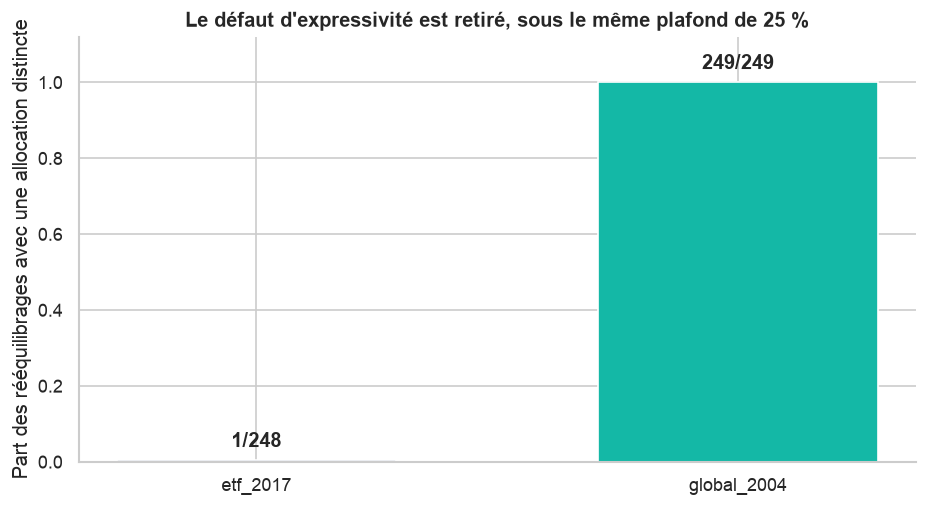

In [3]:
window = readiness["window"]
freedom = readiness["allocation_freedom"]
reference = readiness["reference_comparison"]

readiness_table = pd.DataFrame({
    "Mesure": [
        "Période", "Jours de marché", "Actifs", "Cellules forward-fill",
        "Max. dominance lead/lag", "Allocations distinctes MinVar-LW",
        "Actifs au plafond en moyenne", "Positions effectives moyennes",
    ],
    "Valeur": [
        f"{window['start']} → {window['end']}",
        readiness["provenance"]["data_range"]["n_rows"],
        readiness["provenance"]["data_range"]["n_assets"],
        readiness["coverage"]["forward_filled_cells"],
        readiness["lag_dominance"]["max_lag_dominance"],
        f"{freedom['min_variance_lw']['distinct_allocations']} / {freedom['n_rebalances']}",
        freedom["min_variance_lw"]["mean_assets_at_cap"],
        freedom["min_variance_lw"]["mean_effective_positions"],
    ],
})
display(readiness_table)

labels = ["etf_2017", "global_2004"]
shares = [reference["etf_2017_distinct_share"], freedom["min_variance_lw"]["distinct_share"]]
counts = [
    f"{reference['etf_2017_min_variance_lw_distinct']}/{reference['etf_2017_n_rebalances']}",
    f"{freedom['min_variance_lw']['distinct_allocations']}/{freedom['n_rebalances']}",
]
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(labels, shares, color=["#94a3b8", "#14b8a6"], width=0.58)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Part des rééquilibrages avec une allocation distincte")
ax.set_title("Le défaut d'expressivité est retiré, sous le même plafond de 25 %")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.035,
            count, ha="center", fontweight="bold")
plt.show()

**Lecture autorisée :** `global_2004` retire le défaut d'expressivité de
`etf_2017`. Cela rend l'expérience plus informative ; cela ne constitue encore
aucune preuve de performance.

## 2. Q1 — La stratégie à régimes bat-elle Markowitz ?

Q1 compare une seule stratégie pré-spécifiée, `regime_conditional`, à
`max_sharpe`. Les deux sont évaluées nettes de coûts sur le même segment final
gelé. Le seuil économique exige un gain d'au moins **0,05 point de Sharpe** ; le
test statistique est un bootstrap pairé à blocs sur les mêmes jours.

,Sharpe net,Rendement annualisé géométrique,Max drawdown,Rotation moyenne,Coût cumulé
Stratégie,,,,,
regime_conditional,0.8923,8.10%,-24.22%,0.122,1.11%
max_sharpe,0.9785,9.52%,-25.27%,0.028,0.26%


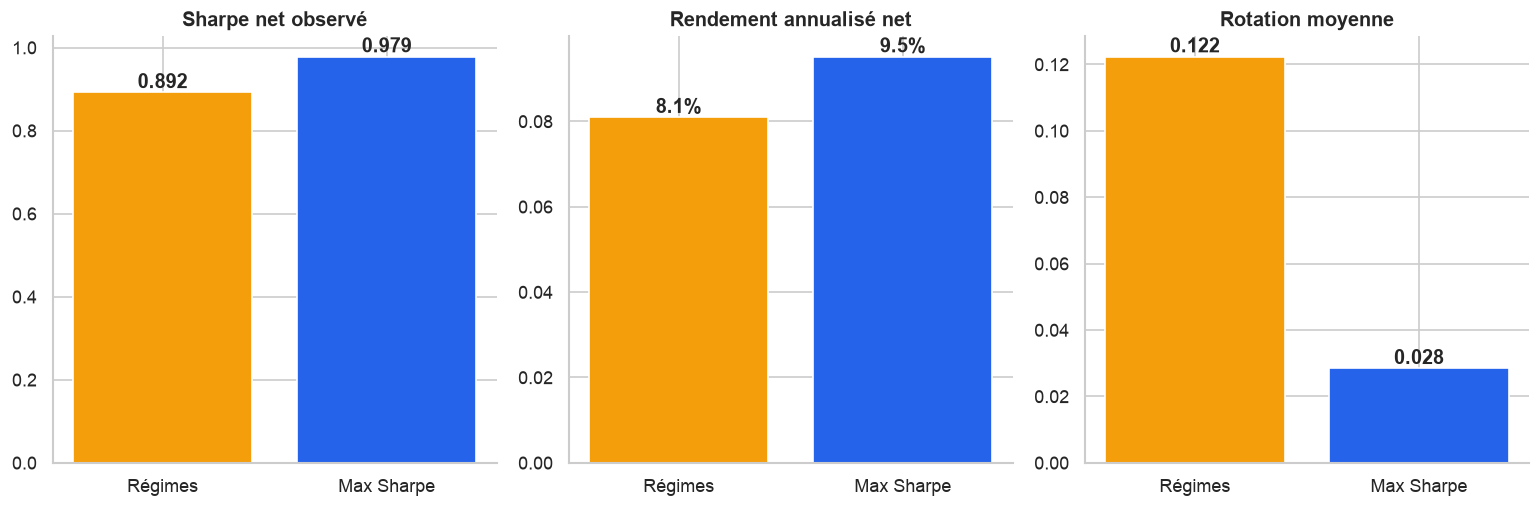

In [4]:
candidate, comparator = q1["candidate"], q1["comparator"]
q1_table = pd.DataFrame([
    {
        "Stratégie": candidate["strategy"],
        "Sharpe net": candidate["net_sharpe"],
        "Rendement annualisé géométrique": candidate["net_geometric_annual_return"],
        "Max drawdown": candidate["max_drawdown"],
        "Rotation moyenne": candidate["avg_turnover"],
        "Coût cumulé": candidate["total_cost_fraction"],
    },
    {
        "Stratégie": comparator["strategy"],
        "Sharpe net": comparator["net_sharpe"],
        "Rendement annualisé géométrique": comparator["net_geometric_annual_return"],
        "Max drawdown": comparator["max_drawdown"],
        "Rotation moyenne": comparator["avg_turnover"],
        "Coût cumulé": comparator["total_cost_fraction"],
    },
]).set_index("Stratégie")
display(q1_table.style.format({
    "Sharpe net": "{:.4f}",
    "Rendement annualisé géométrique": "{:.2%}",
    "Max drawdown": "{:.2%}",
    "Rotation moyenne": "{:.3f}",
    "Coût cumulé": "{:.2%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
colors = [COLORS["regime_conditional"], COLORS["max_sharpe"]]
for ax, field, title, fmt in (
    (axes[0], "Sharpe net", "Sharpe net observé", "{:.3f}"),
    (axes[1], "Rendement annualisé géométrique", "Rendement annualisé net", "{:.1%}"),
    (axes[2], "Rotation moyenne", "Rotation moyenne", "{:.3f}"),
):
    values = q1_table[field].to_numpy()
    bars = ax.bar(["Régimes", "Max Sharpe"], values, color=colors)
    ax.set_title(title)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt.format(value),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

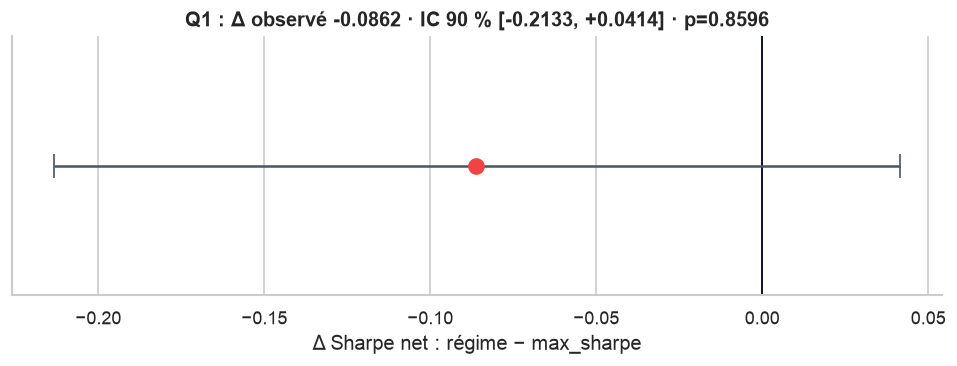

In [5]:
diff = q1["observed_difference"]["net_sharpe_diff"]
lo, hi = q1["paired_inference"]["sharpe_diff_ci"]
p_value = q1["paired_inference"]["one_sided_null_centred_p_value"]

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axvline(0, color="#111827", linewidth=1.2)
ax.errorbar(diff, 0, xerr=[[diff-lo], [hi-diff]], fmt="o", color="#ef4444",
            ecolor="#475569", capsize=7, markersize=9)
ax.set_yticks([])
ax.set_xlabel("Δ Sharpe net : régime − max_sharpe")
ax.set_title(f"Q1 : Δ observé {diff:+.4f} · IC 90 % [{lo:+.4f}, {hi:+.4f}] · p={p_value:.4f}")
plt.show()

**Conclusion Q1 :** aucune surperformance Sharpe de la stratégie à régimes n'est
établie. L'écart observé est défavorable et l'intervalle traverse zéro ; cela ne
démontre pas non plus la supériorité de `max_sharpe`. La stratégie à régimes
affiche une rotation environ 4,3 fois plus élevée et un drawdown maximal légèrement
moins sévère : elle ne perd donc pas sur toutes les dimensions du risque.

## 3. Q2 — Le meilleur RF/XGBoost parmi 240 essais est-il crédible ?

Q2 teste une **famille**, pas une configuration isolée. Toutes les combinaisons
atteignables d'hyperparamètres et de leviers sont conservées. White Reality Check
et Hansen SPA évaluent le meilleur différentiel après avoir intégré le fait qu'il
a été choisi parmi 240 possibilités.

In [6]:
family_rows = []
for endpoint, label in (("primary_sharpe", "Primaire : Sharpe"),
                        ("secondary_mean_return", "Secondaire : rendement moyen")):
    block = q2["family_tests"][endpoint]
    family_rows.append({
        "Critère": label,
        "White RC p": block["reality_check_p_value"],
        "Hansen SPA p": block["spa_p_value"],
        "Candidats > référence": f"{block['n_candidates_beating_benchmark']}/{block['n_candidates']}",
        "Meilleur différentiel observé": block["best_differential"],
    })
display(pd.DataFrame(family_rows).set_index("Critère").style.format({
    "White RC p": "{:.4f}", "Hansen SPA p": "{:.4f}",
    "Meilleur différentiel observé": "{:+.6f}",
}))

,White RC p,Hansen SPA p,Candidats > référence,Meilleur différentiel observé
Critère,,,,
Primaire : Sharpe,0.9045,0.8656,17/240,+0.093015
Secondaire : rendement moyen,0.4568,0.3578,92/240,+0.000101


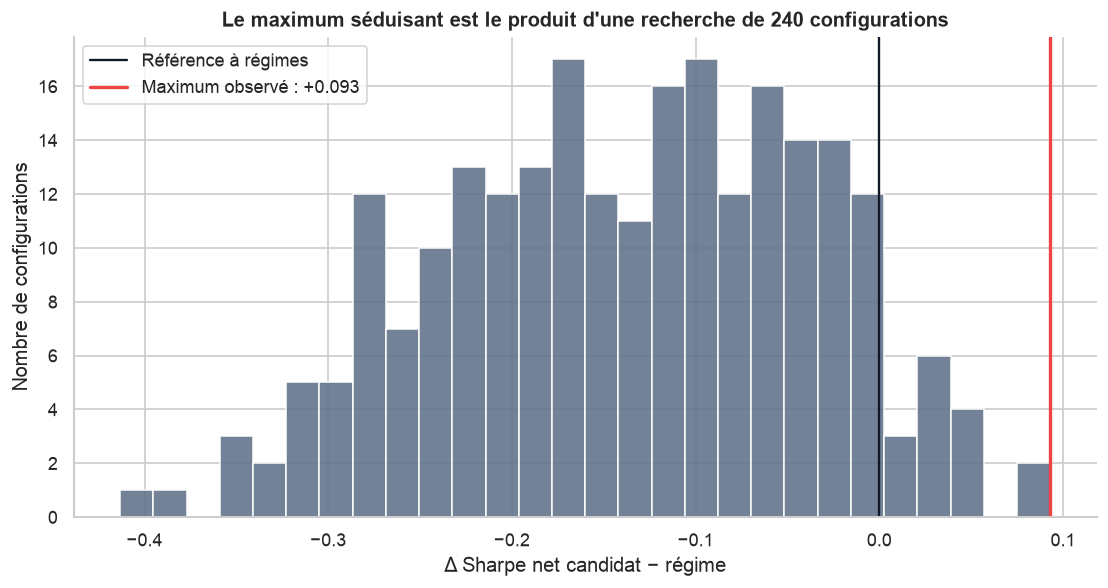

**Verdict familial :** White RC p = `0.9045`, Hansen SPA p = `0.8656`. Le maximum observé `+0.0930` n'est pas une preuve de surperformance.

In [7]:
wide = q2_series.pivot(index="Date", columns="candidate", values="net_return")
benchmark_returns = wide["regime_conditional"]

def net_sharpe(series):
    return float(series.mean() / series.std(ddof=1) * np.sqrt(252))

benchmark_sharpe = net_sharpe(benchmark_returns)
candidate_columns = [c for c in wide.columns if c != "regime_conditional"]
sharpe_diffs = pd.Series(
    {name: net_sharpe(wide[name]) - benchmark_sharpe for name in candidate_columns},
    name="Δ Sharpe vs régime",
)
primary = q2["family_tests"]["primary_sharpe"]
assert len(sharpe_diffs) == q2["candidate_ledger"]["executed_count"] == 240
assert int((sharpe_diffs > 0).sum()) == primary["n_candidates_beating_benchmark"] == 17
assert np.isclose(sharpe_diffs.max(), primary["best_differential"], atol=1e-6)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.hist(sharpe_diffs, bins=28, color="#64748b", edgecolor="white", alpha=0.9)
ax.axvline(0, color="#111827", linewidth=1.4, label="Référence à régimes")
ax.axvline(sharpe_diffs.max(), color="#ef4444", linewidth=2,
           label=f"Maximum observé : {sharpe_diffs.max():+.3f}")
ax.set_xlabel("Δ Sharpe net candidat − régime")
ax.set_ylabel("Nombre de configurations")
ax.set_title("Le maximum séduisant est le produit d'une recherche de 240 configurations")
ax.legend()
plt.show()

display(Markdown(
    f"**Verdict familial :** White RC p = `{primary['reality_check_p_value']:.4f}`, "
    f"Hansen SPA p = `{primary['spa_p_value']:.4f}`. Le maximum observé "
    f"`{sharpe_diffs.max():+.4f}` n'est pas une preuve de surperformance."
))

## 4. Qu'aurait choisi un praticien sans regarder le test ?

Les configurations « déployables » sont choisies uniquement sur entraînement et
validation, par sélection walk-forward. Leur performance finale est descriptive :
aucun test pairé individuel n'a été pré-spécifié pour démontrer qu'elles sont
inférieures à la référence.

,Sharpe net observé,Δ vs régime,Rendement annualisé géométrique
Stratégie,,,
regime_conditional,0.8923,+0.0000,8.10%
rf_signal_tuned,0.8266,-0.0657,7.78%
xgb_signal_tuned,0.8025,-0.0898,8.05%


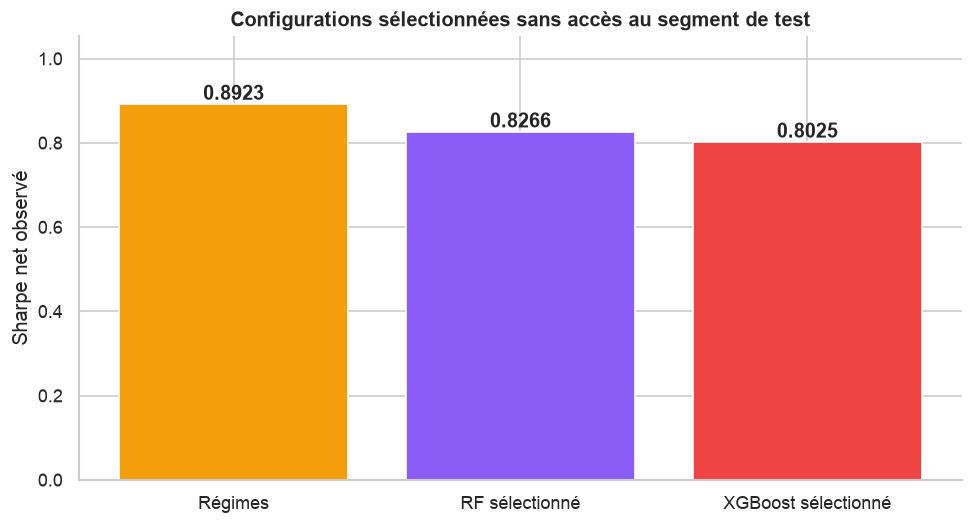

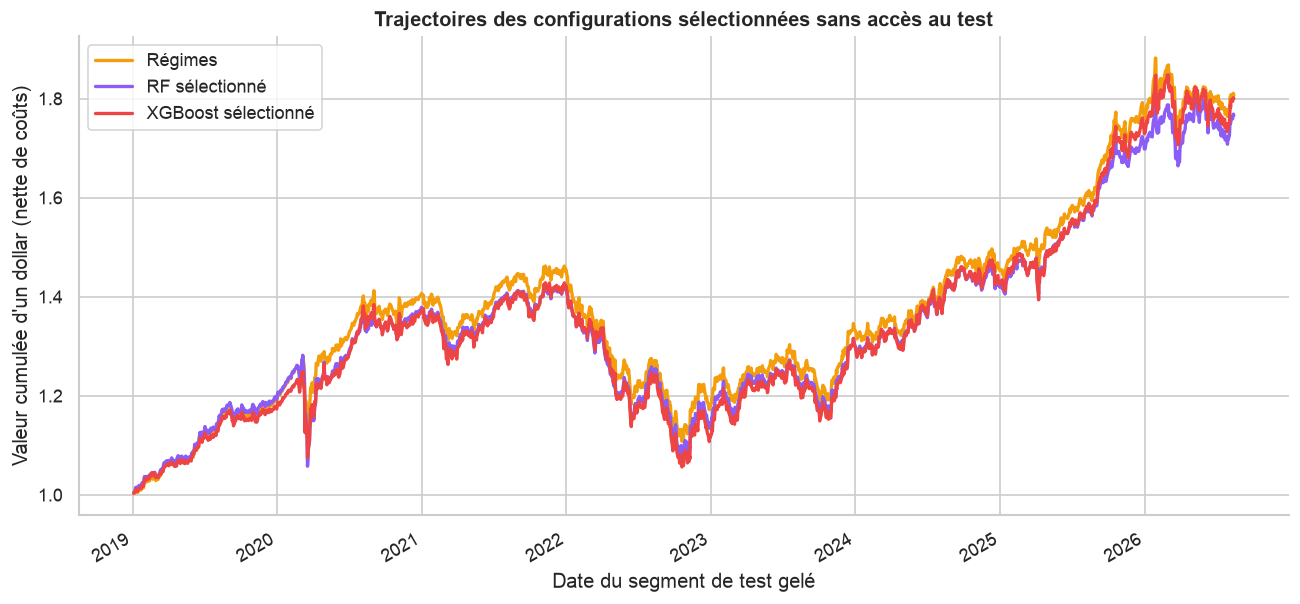

In [8]:
def candidate_label(spec):
    params = "_".join(f"{k}={v}" for k, v in sorted(spec["ml_params"].items()))
    return (f"{spec['model_type']}__{params}__shrink={spec['shrinkage_weight']}"
            f"__pen={spec['turnover_penalty']}")

def geometric_annual_return(series):
    return float((1 + series).prod() ** (252 / len(series)) - 1)

selected_return_series = {"regime_conditional": benchmark_returns}
selected_rows = [{
    "Stratégie": "regime_conditional",
    "Sharpe net observé": benchmark_sharpe,
    "Δ vs régime": 0.0,
    "Rendement annualisé géométrique": geometric_annual_return(benchmark_returns),
}]
for display_name, spec in q2["deployable_challengers"].items():
    label = candidate_label(spec)
    selected_returns = wide[label]
    selected_return_series[display_name] = selected_returns
    selected_sharpe = net_sharpe(selected_returns)
    selected_rows.append({
        "Stratégie": display_name,
        "Sharpe net observé": selected_sharpe,
        "Δ vs régime": selected_sharpe - benchmark_sharpe,
        "Rendement annualisé géométrique": geometric_annual_return(selected_returns),
    })
selected = pd.DataFrame(selected_rows).set_index("Stratégie")
display(selected.style.format({
    "Sharpe net observé": "{:.4f}", "Δ vs régime": "{:+.4f}",
    "Rendement annualisé géométrique": "{:.2%}",
}))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_values = selected["Sharpe net observé"]
bars = ax.bar(["Régimes", "RF sélectionné", "XGBoost sélectionné"], plot_values,
              color=[COLORS["regime_conditional"], COLORS["rf_signal_tuned"], COLORS["xgb_signal_tuned"]])
ax.set_ylim(0, max(plot_values) * 1.18)
ax.set_ylabel("Sharpe net observé")
ax.set_title("Configurations sélectionnées sans accès au segment de test")
for bar, value in zip(bars, plot_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{value:.4f}", ha="center", fontweight="bold")
plt.show()

growth = pd.DataFrame({
    name: (1 + returns).cumprod()
    for name, returns in selected_return_series.items()
}).rename(columns={
    "regime_conditional": "Régimes",
    "rf_signal_tuned": "RF sélectionné",
    "xgb_signal_tuned": "XGBoost sélectionné",
})
ax = growth.plot(
    figsize=(11, 5.2), linewidth=2,
    color=[COLORS["regime_conditional"], COLORS["rf_signal_tuned"], COLORS["xgb_signal_tuned"]],
)
ax.set_ylabel("Valeur cumulée d'un dollar (nette de coûts)")
ax.set_xlabel("Date du segment de test gelé")
ax.set_title("Trajectoires des configurations sélectionnées sans accès au test")
ax.legend(title=None)
plt.tight_layout()
plt.show()

In [9]:
telemetry = q2["fallback_telemetry"]
selected_fallbacks = {}
for name, spec in q2["deployable_challengers"].items():
    selected_fallbacks[name] = telemetry["candidates"][candidate_label(spec)]["fallback_count"]

telemetry_table = pd.DataFrame({
    "Périmètre": ["Référence à régimes", "Famille des 240 candidats", "RF sélectionné", "XGBoost sélectionné"],
    "Fallbacks": [telemetry["benchmark"]["fallback_count"], telemetry["total_candidate_fallbacks"],
                  selected_fallbacks["rf_signal_tuned"], selected_fallbacks["xgb_signal_tuned"]],
    "Fits": [telemetry["benchmark"]["n_fits"], 240 * 249, 249, 249],
})
telemetry_table["Taux"] = telemetry_table["Fallbacks"] / telemetry_table["Fits"]
display(telemetry_table.style.format({"Taux": "{:.4%}"}))

,Périmètre,Fallbacks,Fits,Taux
0,Référence à régimes,3,249,1.2048%
1,Famille des 240 candidats,1,59760,0.0017%
2,RF sélectionné,0,249,0.0000%
3,XGBoost sélectionné,0,249,0.0000%


## 5. Conclusion générale

### Succès d'ingénierie
Une chaîne Bronze/Silver/Gold versionnée, des contrats de données, une validation
sans fuite, une télémétrie des fallbacks et 241 séries comparables ont été produits.

### Succès méthodologique
Le nouvel univers retire les défauts d'expressivité et de décalage de marché qui
limitaient les deux univers précédents. La pré-inscription et la correction RC/SPA
empêchent de transformer le meilleur résultat brut d'une recherche en conclusion.

### Résultat économique
Aucun avantage Sharpe du modèle à régimes ou de la famille RF/XGBoost n'est établi
sur `global_2004`. Le meilleur différentiel brut parmi 240 candidats ne résiste pas
à la correction, et les deux challengers honnêtement sélectionnés affichent un
Sharpe net observé inférieur à la référence.

### Limites
Q2 change simultanément la coupe d'actifs et la politique de variables macro ; son
résultat ne peut donc pas être attribué au seul élargissement de l'univers. Le choix
externe de construire `global_2004` après diagnostic des univers précédents n'est
pas corrigé par RC/SPA. Enfin, il s'agit d'un prototype de recherche en USD, sans
exécution d'ordres ni recommandation d'investissement.